# Customer Churn Analysis

## Objective
The goal of this project is to analyze customer behavior and identify key factors contributing to customer churn.

We will:
- Explore multiple data sources (demographics, transactions, service, online activity)
- Perform data cleaning and feature engineering
- Identify patterns related to churn
- Prepare a dataset suitable for predictive modeling

## Dataset Overview
The dataset consists of 5 tables:

1. Customer_Demographics → Customer personal details
2. Transaction_History → Customer financial transactions
3. Customer_Service → Complaints and service interactions
4. Online_Activity → Digital engagement data
5. Churn_Status → Target variable (whether customer churned or not)

## 1. Import Libraries & Configuration

In [28]:
# Libraries
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 
warnings.filterwarnings('ignore')

# Configurations
sns.set_style('darkgrid')
# plt.rcParams['figure.figsize']=(10,6)

## 2. Load Dataset

In [2]:
# Define dataset path
file_path = "../data/Customer_Churn_Data_Large.xlsx"
data = pd.ExcelFile(file_path)

# Load each dataset from Excel sheets
customer_demographics = pd.read_excel(file_path, sheet_name= "Customer_Demographics")
transaction_history = pd.read_excel(file_path, sheet_name= "Transaction_History")
customer_service = pd.read_excel(file_path, sheet_name= "Customer_Service")
online_activity = pd.read_excel(file_path, sheet_name= "Online_Activity")
churn_status = pd.read_excel(file_path, sheet_name= "Churn_Status")

# Check sheet lists
print(f"Total sheets in the dataset - {data.sheet_names}")

Total sheets in the dataset - ['Customer_Demographics', 'Transaction_History', 'Customer_Service', 'Online_Activity', 'Churn_Status']


## 3. Exploratory Data Analysis (EDA)

In [32]:
# Define inspect fucntion for quick data inspection
def inspect(df, name):
    print(f"\n{name}")
    print("-"*40)

    print("Sample Records:")
    print(df.head())
    
    print("\nShape:")
    print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
    
    print("\nData Info:")
    df.info()
    
    print("\nMissing Values:")
    print(df.isnull().sum())
    
    print(f"\nDuplicated Rows: {df.duplicated().sum()}")
    
    print("\nStatistical Summary:")
    print(df.describe())
    print("\n")



#### Dataset 1 - Customer Demographics :

In [33]:
inspect(customer_demographics, "Customer Demographics")


Customer Demographics
----------------------------------------
Sample Records:
   CustomerID  Age Gender MaritalStatus IncomeLevel
0           1   62      M        Single         Low
1           2   65      M       Married         Low
2           3   18      M        Single         Low
3           4   21      M       Widowed         Low
4           5   21      M      Divorced      Medium

Shape:
Rows: 1000, Columns: 5

Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   CustomerID     1000 non-null   int64
 1   Age            1000 non-null   int64
 2   Gender         1000 non-null   str  
 3   MaritalStatus  1000 non-null   str  
 4   IncomeLevel    1000 non-null   str  
dtypes: int64(2), str(3)
memory usage: 39.2 KB

Missing Values:
CustomerID       0
Age              0
Gender           0
MaritalStatus    0
IncomeLevel      0
dtype: int64

Dupl

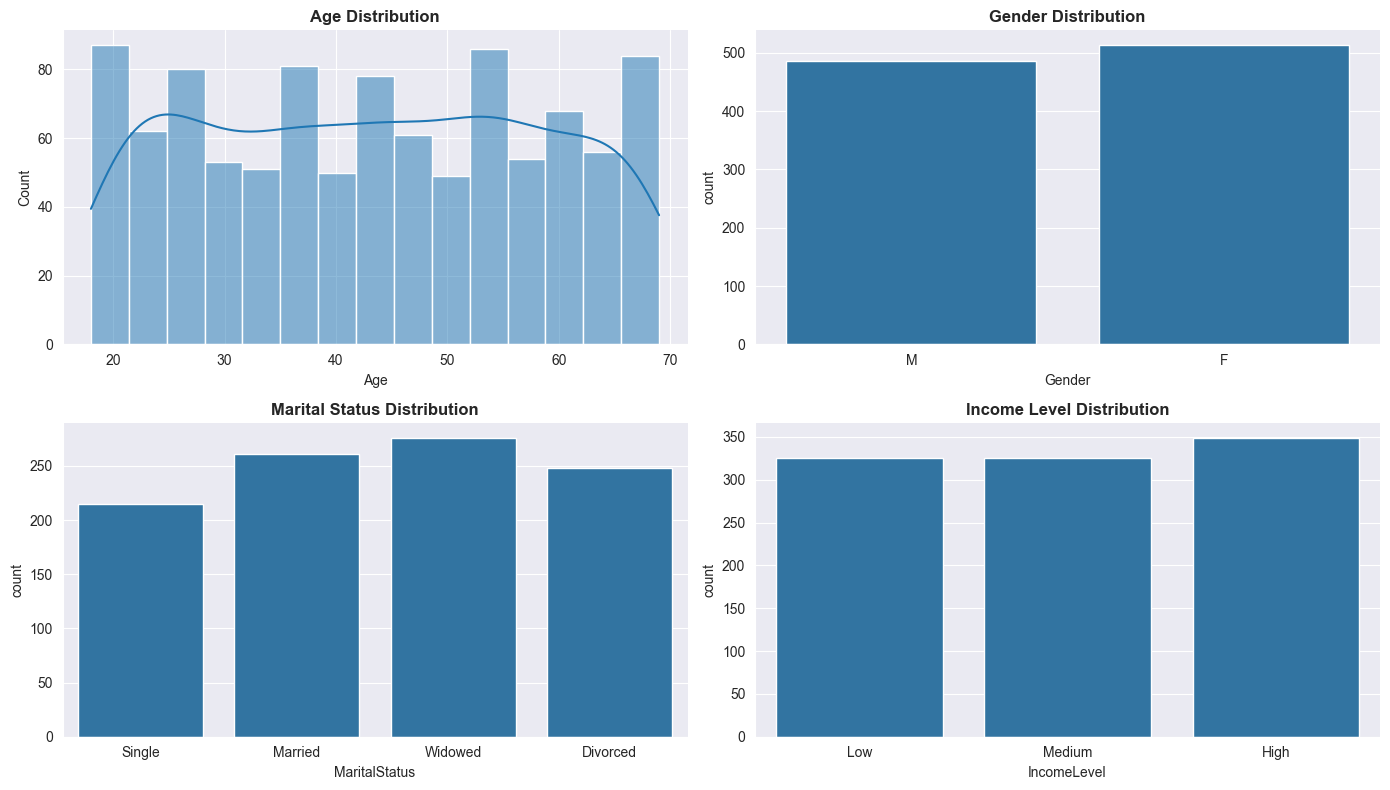

In [34]:
plt.figure(figsize=(14,8))

# Age Distribution
plt.subplot(2,2,1)
sns.histplot(data=customer_demographics, x='Age',bins=15, kde=True)
plt.title('Age Distribution', fontweight='bold')
sns.despine()

# Gender Distribution
plt.subplot(2,2,2)
sns.countplot(data=customer_demographics, x='Gender')
plt.title('Gender Distribution', fontweight='bold')
sns.despine()

# Marital Status Distribution
plt.subplot(2,2,3)
sns.countplot(data=customer_demographics, x='MaritalStatus')
plt.title('Marital Status Distribution', fontweight='bold')
sns.despine()

# Income Level Distribution
plt.subplot(2,2,4)
sns.countplot(data=customer_demographics, x='IncomeLevel')
plt.title('Income Level Distribution', fontweight='bold')
sns.despine()

plt.tight_layout()
plt.show()

#### Observations :
- There are 1000 rows and 5 columns in this dataset.
- The dataset contains no missing or duplicate values.
- Customer ages are distributed fairly evenly between 18 and 69 years, with an average age of approximately 43 years.
- In Gender, number of female customers are slightly higher compared to male customers.
- Widowed customers are slightly higher in number compared to other marital status categories.
- Income levels are also fairly balanced among Low, Medium, and High categories, with High income customers slightly dominating the dataset.
- No major skewness or abnormal patterns are visible in demographic features at the initial exploration stage.